In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


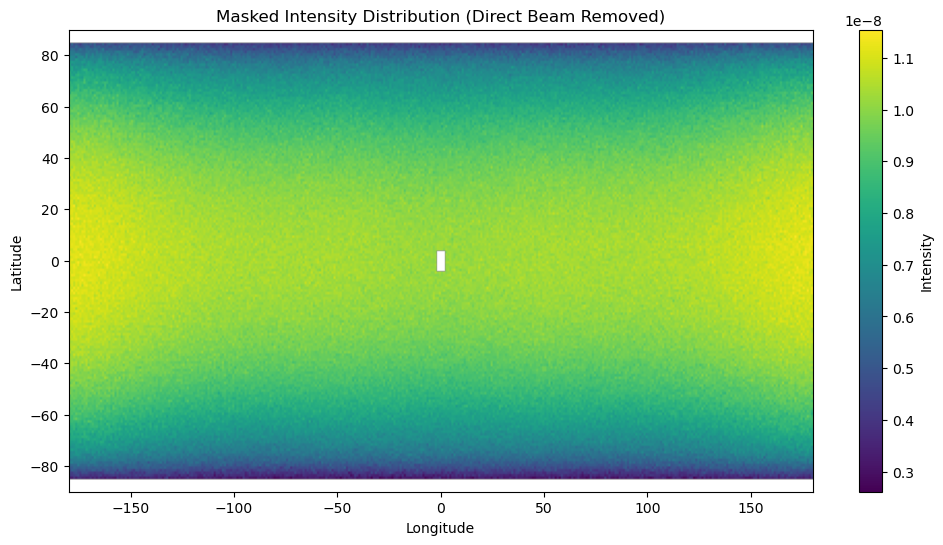

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_99251/1065460397.py:96: RuntimeWarning: Mean of empty slice
  meridian_cut = np.nanmean(meridian_band, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_99251/1065460397.py:100: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,


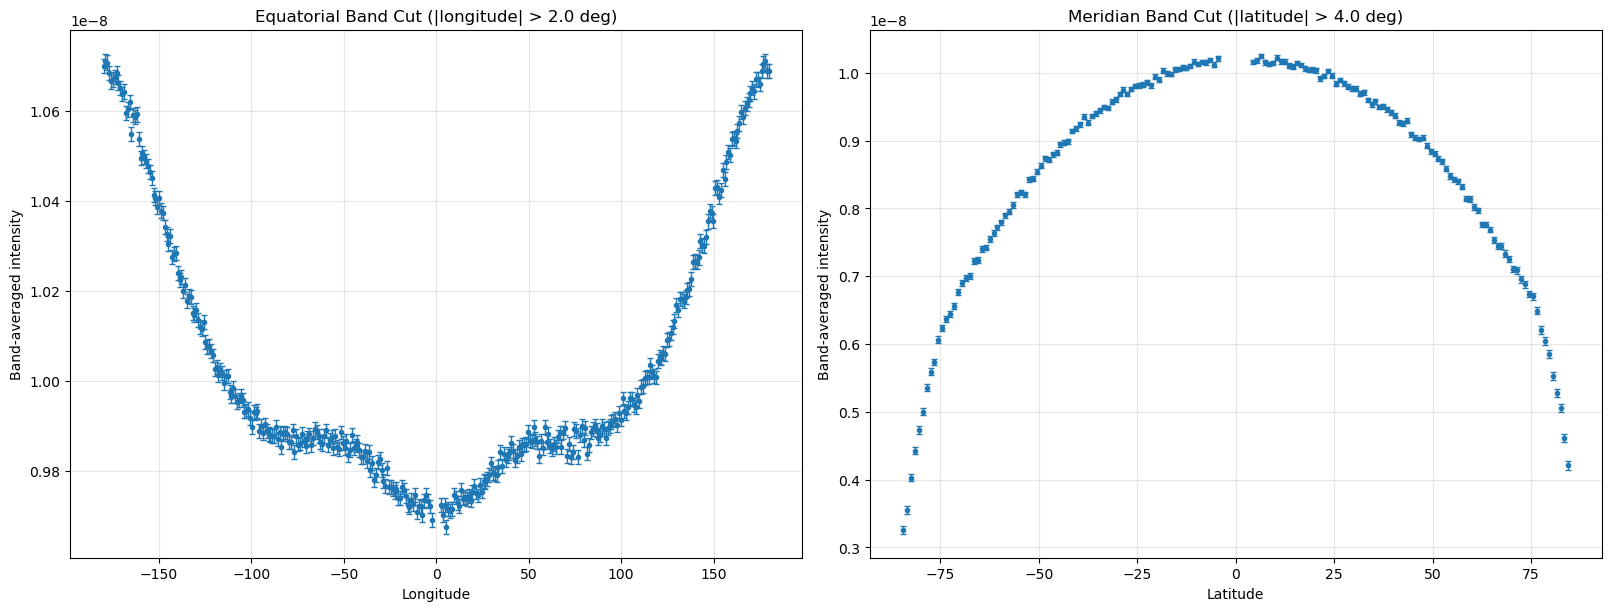

In [37]:
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/2mm")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
hits_err = sphere_mon.Error
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = np.array(hits, copy=True)
Hmc_err = np.array(hits_err, copy=True)

# Ensure the array layout is (latitude, longitude).
if hasattr(meta, "dimension") and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T

pole_cut_deg = 5.0
lat_centers = np.linspace(ymin + 0.5 * (ymax - ymin) / Hmc.shape[0], ymax - 0.5 * (ymax - ymin) / Hmc.shape[0], Hmc.shape[0])
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg (last {pole_cut_deg:.1f} deg near each pole)")

safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
Hmc_corrected = Hmc / safe_cos
Hmc_err_corrected = Hmc_err / safe_cos
Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Define angular grid
# ------------------------------------------------------------
lon = np.linspace(xmin, xmax, Hmc_corrected.shape[1])
lat = lat_centers
Lon, Lat = np.meshgrid(lon, lat)

# ------------------------------------------------------------
# Beam mask (from your calibration)
# ------------------------------------------------------------
beam_lon_halfwidth_deg = 2.0
beam_lat_halfwidth_deg = 4.0

beam_mask = (
    (np.abs(Lon) <= beam_lon_halfwidth_deg) &
    (np.abs(Lat) <= beam_lat_halfwidth_deg)
)

# Combine with pole mask
full_mask = pole_mask[:, np.newaxis] & (~beam_mask)

# ------------------------------------------------------------
# Apply mask to corrected data
# ------------------------------------------------------------
Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Plot masked map
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.imshow(Hmc_masked, extent=extent, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Masked Intensity Distribution (Direct Beam Removed)')
plt.show()

# ------------------------------------------------------------
# Equator band cut (mask-aware)
# ------------------------------------------------------------
equator_band_halfwidth = 50.0  # degrees
equator_band_mask = np.abs(lat) <= equator_band_halfwidth

equator_band = Hmc_masked[equator_band_mask, :]
equator_band_err = Hmc_err_masked[equator_band_mask, :]

equator_cut = np.nanmean(equator_band, axis=0)
valid_counts = np.sum(~np.isnan(equator_band), axis=0)
equator_cut_err = np.where(
    valid_counts > 0,
    np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
    np.nan,
)
valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)

lon_plot = lon[valid_cols]
equator_cut_plot = equator_cut[valid_cols]
equator_cut_err_plot = equator_cut_err[valid_cols]

# ------------------------------------------------------------
# Meridian band cut (mask-aware)
# ------------------------------------------------------------
meridian_band_halfwidth = 10.0  # degrees around longitude = 0
meridian_band_mask = np.abs(lon) <= meridian_band_halfwidth

meridian_band = Hmc_masked[:, meridian_band_mask]
meridian_band_err = Hmc_err_masked[:, meridian_band_mask]

meridian_cut = np.nanmean(meridian_band, axis=1)
meridian_valid_counts = np.sum(~np.isnan(meridian_band), axis=1)
meridian_cut_err = np.where(
    meridian_valid_counts > 0,
    np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,
    np.nan,
)
valid_rows = (meridian_valid_counts > 0) & (np.abs(lat) > beam_lat_halfwidth_deg)

lat_plot = lat[valid_rows]
meridian_cut_plot = meridian_cut[valid_rows]
meridian_cut_err_plot = meridian_cut_err[valid_rows]

fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axs[0].errorbar(lon_plot, equator_cut_plot, yerr=equator_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Band-averaged intensity')
axs[0].set_title(f'Equatorial Band Cut (|longitude| > {beam_lon_halfwidth_deg:.1f} deg)')
axs[0].grid(True, alpha=0.3)

axs[1].errorbar(lat_plot, meridian_cut_plot, yerr=meridian_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[1].set_xlabel('Latitude')
axs[1].set_ylabel('Band-averaged intensity')
axs[1].set_title(f'Meridian Band Cut (|latitude| > {beam_lat_halfwidth_deg:.1f} deg)')
axs[1].grid(True, alpha=0.3)

plt.show()


run 12: thickness=1.758 mm, const=9.332278e-09 +/- 1.494471e-12, weighted_rms=1.658227e-11, red_chi2=1.244, n=100
run 10: thickness=1.632 mm, const=9.003892e-09 +/- 1.470685e-12, weighted_rms=1.678233e-11, red_chi2=1.315, n=100
run 13: thickness=1.821 mm, const=9.485429e-09 +/- 1.505275e-12, weighted_rms=1.724376e-11, red_chi2=1.326, n=100
run 0: thickness=1.000 mm, const=6.779954e-09 +/- 1.290273e-12, weighted_rms=1.480504e-11, red_chi2=1.330, n=100
run 11: thickness=1.695 mm, const=9.171268e-09 +/- 1.482827e-12, weighted_rms=1.710764e-11, red_chi2=1.345, n=100
run 8: thickness=1.505 mm, const=8.641145e-09 +/- 1.443614e-12, weighted_rms=1.701409e-11, red_chi2=1.403, n=100
run 14: thickness=1.884 mm, const=9.631541e-09 +/- 1.515511e-12, weighted_rms=1.818771e-11, red_chi2=1.455, n=100
run 16: thickness=2.011 mm, const=9.898900e-09 +/- 1.533688e-12, weighted_rms=1.950207e-11, red_chi2=1.633, n=100
run 15: thickness=1.947 mm, const=9.770593e-09 +/- 1.525021e-12, weighted_rms=1.963072e-11

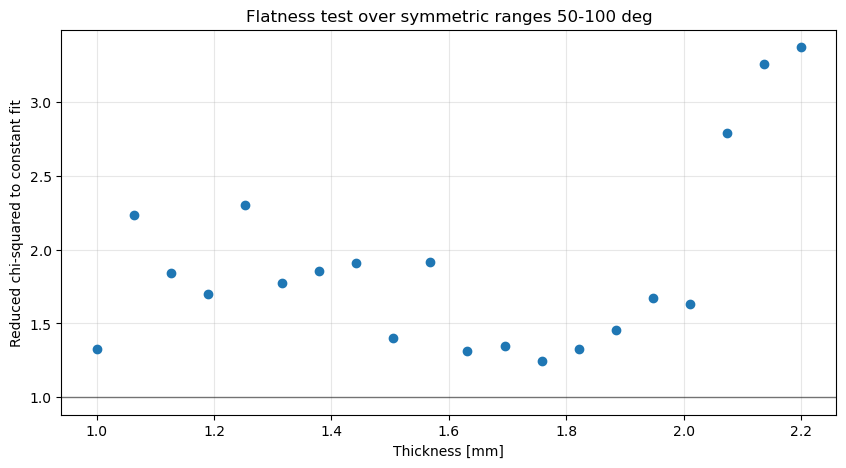

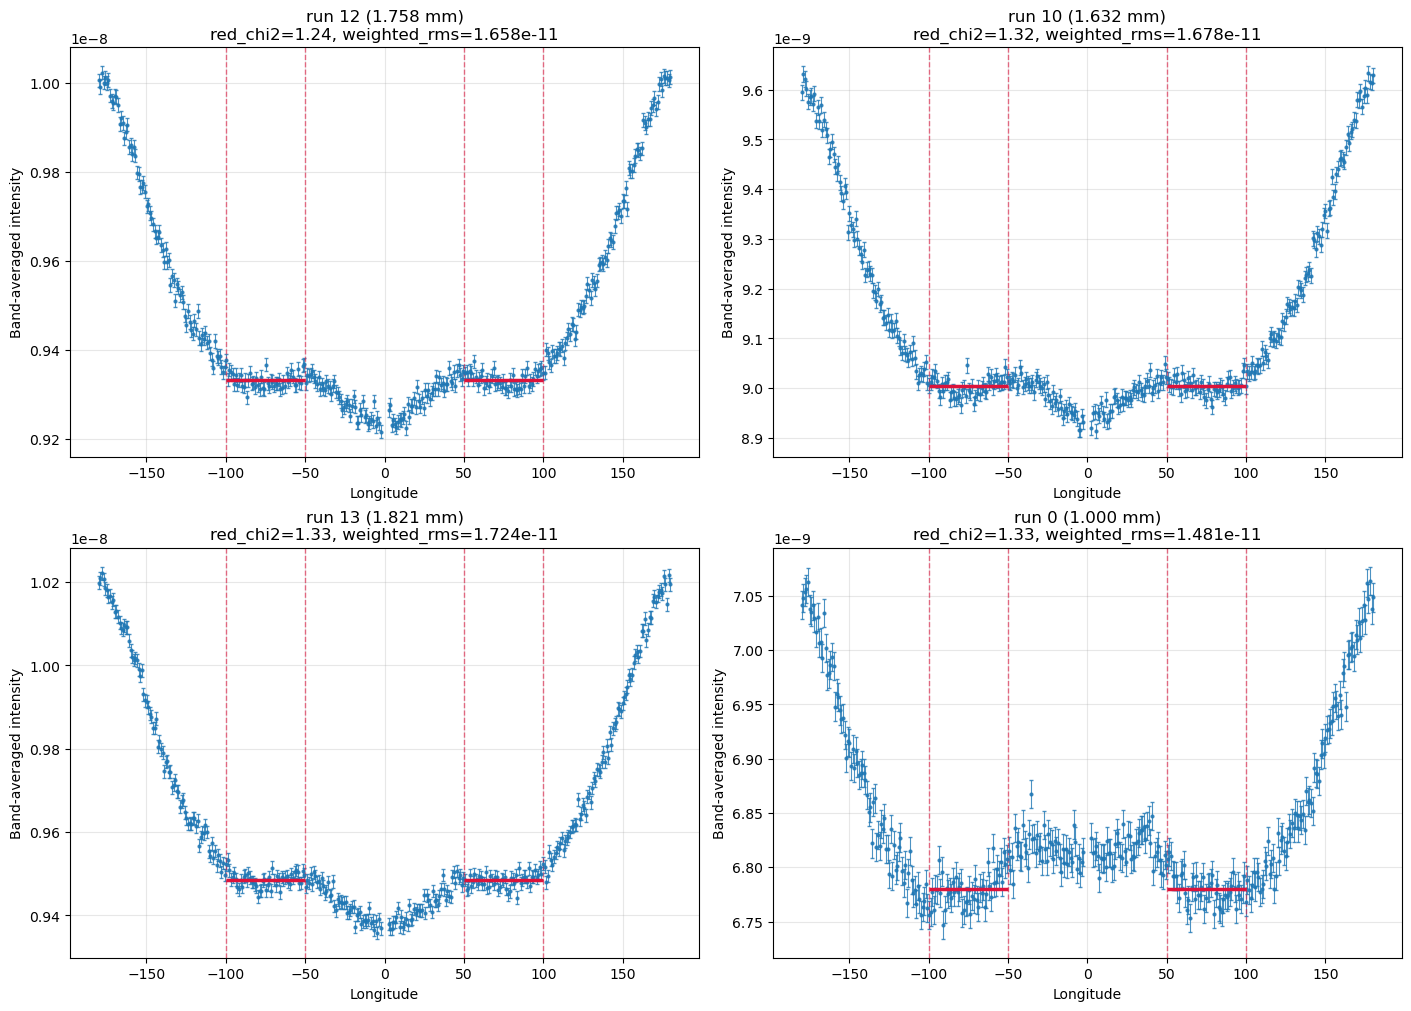

In [51]:
# Flatness test of thickness-scan equatorial cuts using symmetric side windows
fit_min_deg = 50.0
fit_max_deg = 100.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1_to_2p2_1e9')
run_indices = list(range(20))
thicknesses_mm = np.linspace(1.0, 2.2, len(run_indices))
results = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])
    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos
    pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
    Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_mask = (np.abs(Lon) <= beam_lon_halfwidth_deg) & (np.abs(Lat) <= beam_lat_halfwidth_deg)
    full_mask = pole_mask[:, np.newaxis] & (~beam_mask)
    Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
    Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_masked[equator_band_mask, :]
    equator_band_err = Hmc_err_masked[equator_band_mask, :]

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)
    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))

    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'fit_x': x,
        'fit_y': y,
        'fit_sigma': sigma,
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results = sorted(results, key=lambda r: abs(r['red_chi2'] - 1.0))

for r in results:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, n={r['n_points']}"
    )

best = results[0]
print('')
print(
    f"Flattest in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

plt.figure(figsize=(10, 5))
plt.plot([r['thickness_mm'] for r in results], [r['red_chi2'] for r in results], 'o')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title(f'Flatness test over symmetric ranges {fit_min_deg:.0f}-{fit_max_deg:.0f} deg')
plt.grid(True, alpha=0.3)
plt.show()

best_four = results[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


run 4: thickness=1.678 mm, const=9.128568e-09 +/- 1.479751e-12, weighted_rms=1.545711e-11, red_chi2=1.102, n=100
run 5: thickness=1.722 mm, const=9.245627e-09 +/- 1.488247e-12, weighted_rms=1.723960e-11, red_chi2=1.355, n=100
run 0: thickness=1.500 mm, const=8.624401e-09 +/- 1.442311e-12, weighted_rms=1.683142e-11, red_chi2=1.376, n=100
run 7: thickness=1.811 mm, const=9.464520e-09 +/- 1.503867e-12, weighted_rms=1.812959e-11, red_chi2=1.468, n=100
run 8: thickness=1.856 mm, const=9.565575e-09 +/- 1.510871e-12, weighted_rms=1.828452e-11, red_chi2=1.479, n=100
run 9: thickness=1.900 mm, const=9.667730e-09 +/- 1.517959e-12, weighted_rms=1.842499e-11, red_chi2=1.488, n=100
run 3: thickness=1.633 mm, const=9.008380e-09 +/- 1.470975e-12, weighted_rms=1.806152e-11, red_chi2=1.523, n=100
run 2: thickness=1.589 mm, const=8.883955e-09 +/- 1.461777e-12, weighted_rms=1.878656e-11, red_chi2=1.668, n=100
run 6: thickness=1.767 mm, const=9.354325e-09 +/- 1.495987e-12, weighted_rms=1.954066e-11, red_c

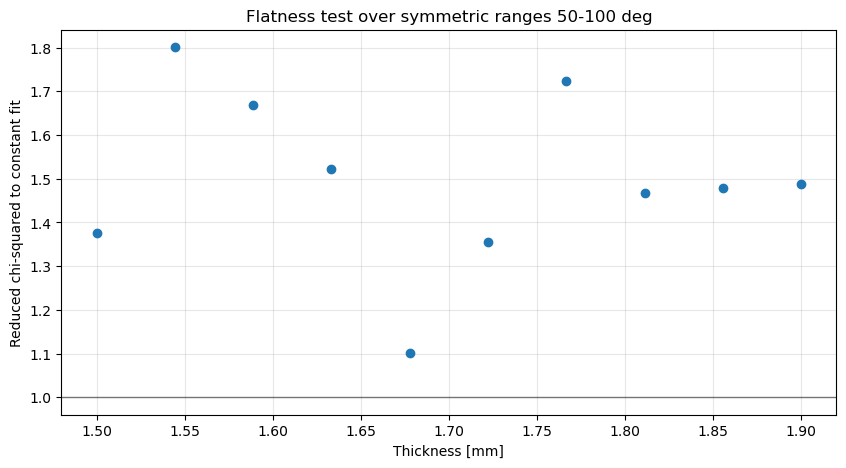

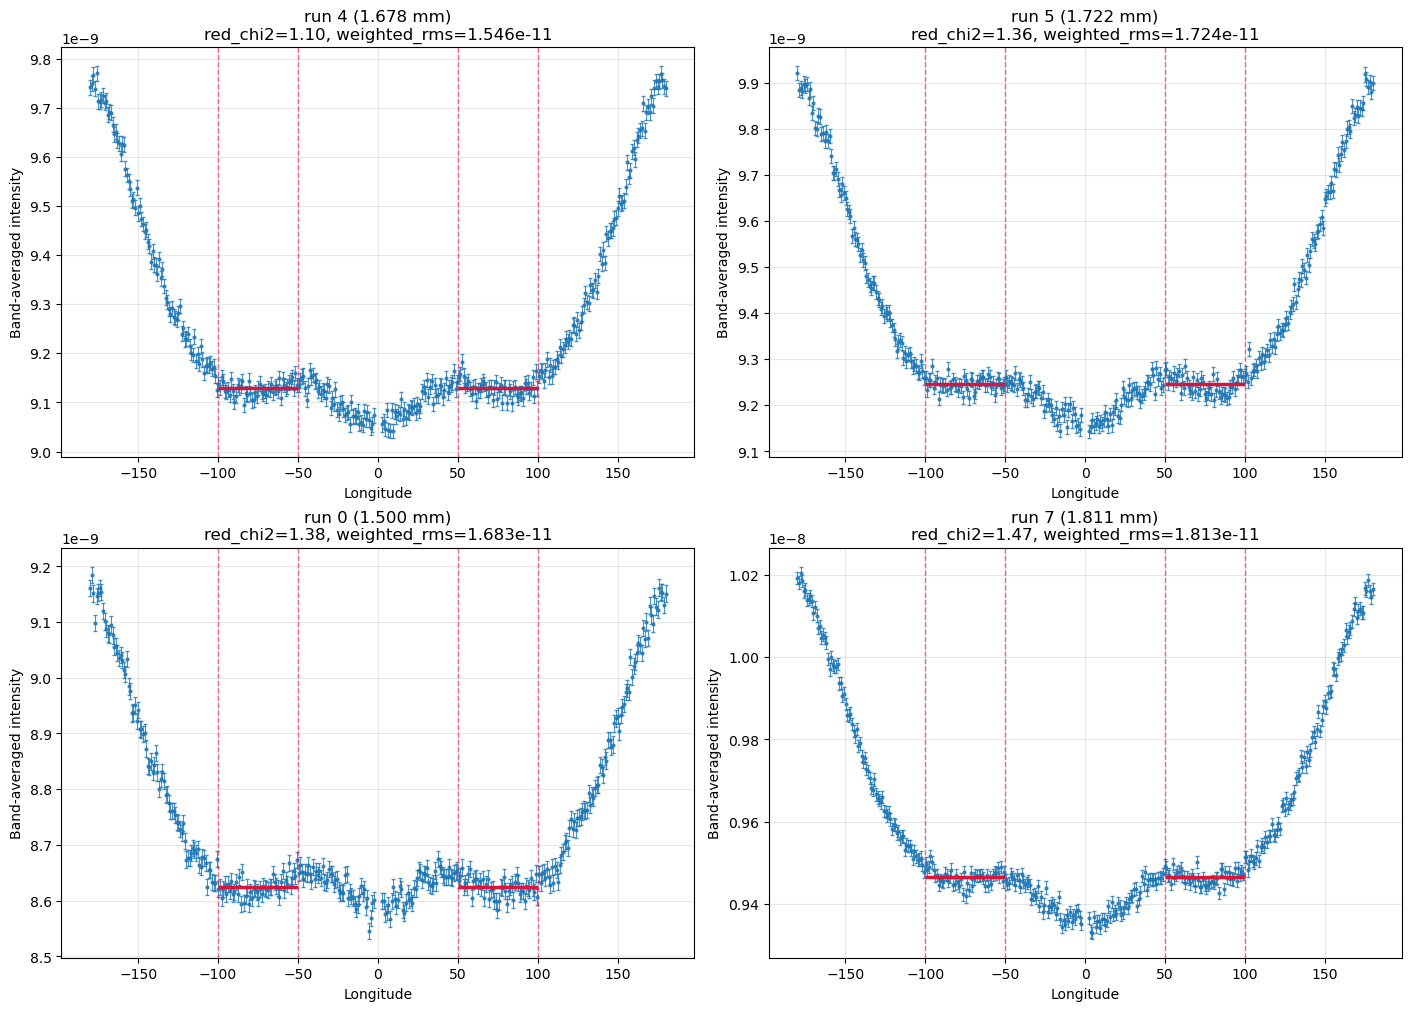

In [53]:
# Flatness test of thickness-scan equatorial cuts using symmetric side windows
fit_min_deg = 50.0
fit_max_deg = 100.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p5to1p9_1e9')
run_indices = list(range(10))
thicknesses_mm = np.linspace(1.5, 1.9, len(run_indices))
results = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])
    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos
    pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
    Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_mask = (np.abs(Lon) <= beam_lon_halfwidth_deg) & (np.abs(Lat) <= beam_lat_halfwidth_deg)
    full_mask = pole_mask[:, np.newaxis] & (~beam_mask)
    Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
    Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_masked[equator_band_mask, :]
    equator_band_err = Hmc_err_masked[equator_band_mask, :]

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)
    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))

    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'fit_x': x,
        'fit_y': y,
        'fit_sigma': sigma,
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results = sorted(results, key=lambda r: abs(r['red_chi2'] - 1.0))

for r in results:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, n={r['n_points']}"
    )

best = results[0]
print('')
print(
    f"Flattest in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

plt.figure(figsize=(10, 5))
plt.plot([r['thickness_mm'] for r in results], [r['red_chi2'] for r in results], 'o')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title(f'Flatness test over symmetric ranges {fit_min_deg:.0f}-{fit_max_deg:.0f} deg')
plt.grid(True, alpha=0.3)
plt.show()

best_four = results[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


run 8: thickness=1.778 mm, const=9.381802e-09 +/- 6.699034e-13, weighted_rms=1.078630e-11, red_chi2=2.619, n=100
run 2: thickness=1.644 mm, const=9.039159e-09 +/- 6.588590e-13, weighted_rms=1.100063e-11, red_chi2=2.816, n=100
run 1: thickness=1.622 mm, const=8.978065e-09 +/- 6.568469e-13, weighted_rms=1.107776e-11, red_chi2=2.873, n=100
run 6: thickness=1.733 mm, const=9.272243e-09 +/- 6.664131e-13, weighted_rms=1.125200e-11, red_chi2=2.880, n=100
run 4: thickness=1.689 mm, const=9.157683e-09 +/- 6.627160e-13, weighted_rms=1.126126e-11, red_chi2=2.917, n=100
run 13: thickness=1.889 mm, const=9.640508e-09 +/- 6.780011e-13, weighted_rms=1.157730e-11, red_chi2=2.945, n=100
run 12: thickness=1.867 mm, const=9.590451e-09 +/- 6.764505e-13, weighted_rms=1.156598e-11, red_chi2=2.953, n=100
run 10: thickness=1.822 mm, const=9.487920e-09 +/- 6.732436e-13, weighted_rms=1.151192e-11, red_chi2=2.953, n=100
run 5: thickness=1.711 mm, const=9.214874e-09 +/- 6.645632e-13, weighted_rms=1.155631e-11, re

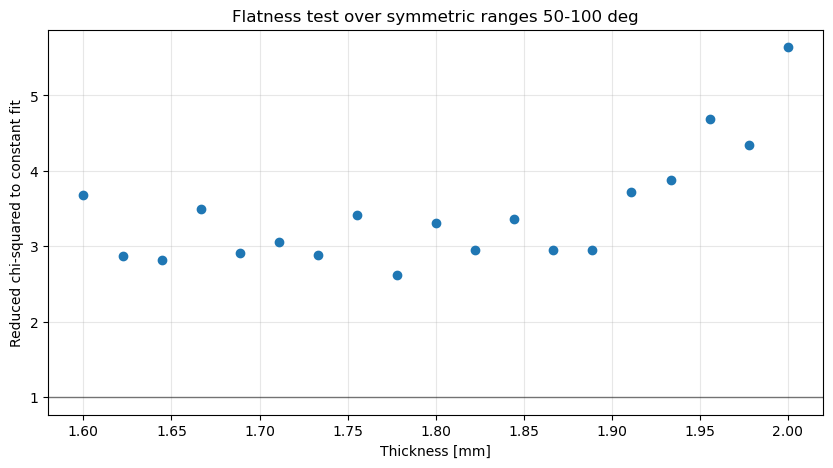

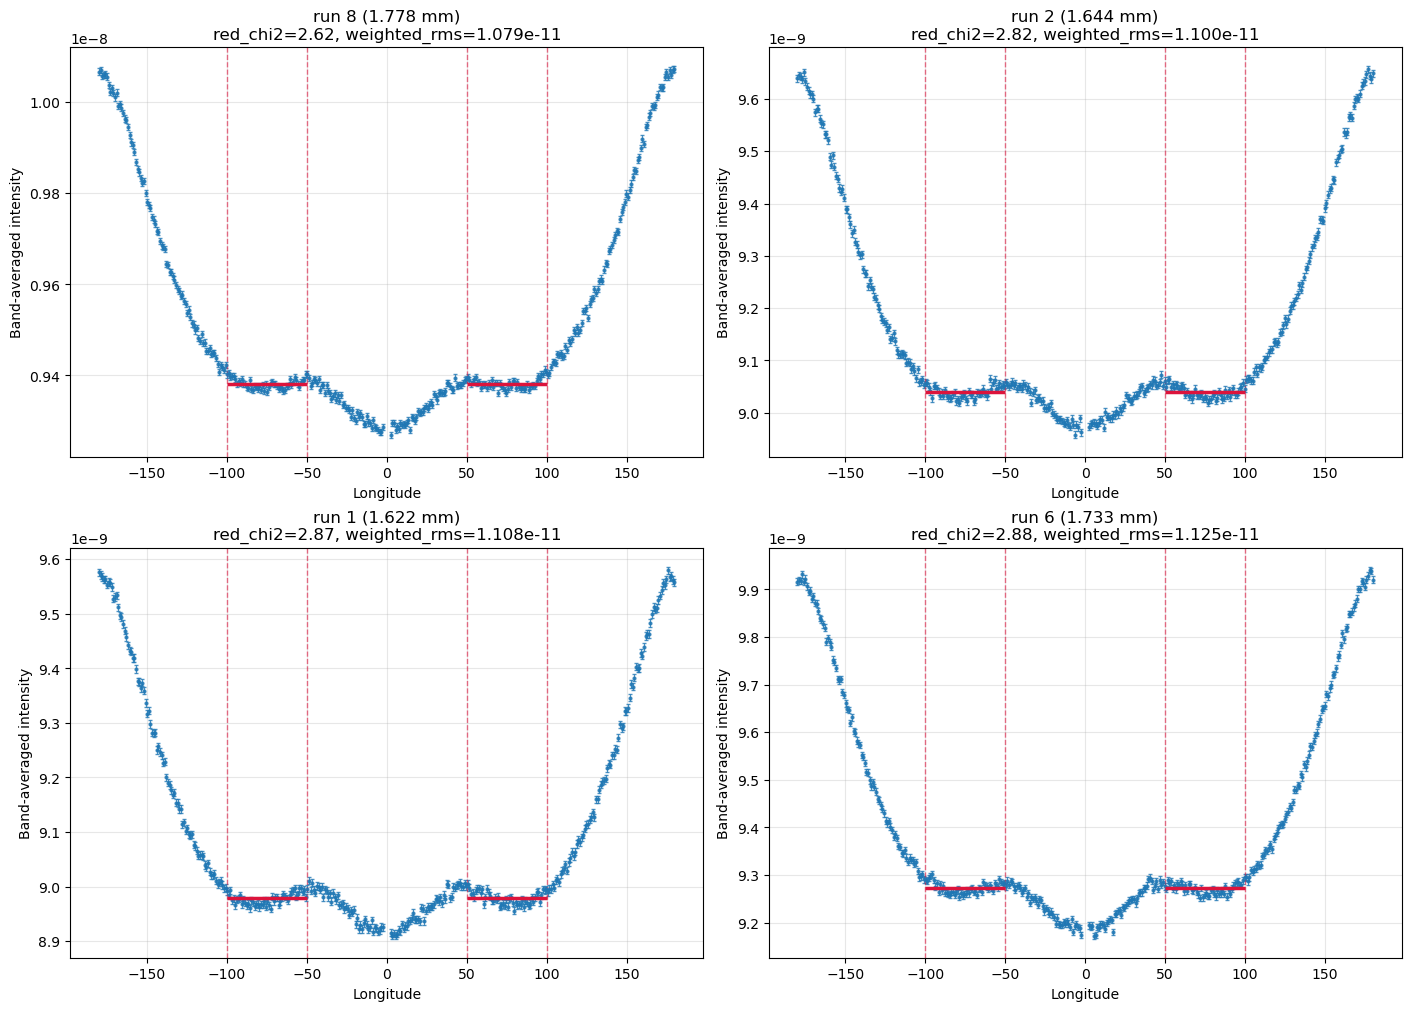

In [58]:
# Flatness test of thickness-scan equatorial cuts using symmetric side windows
fit_min_deg = 50.0
fit_max_deg = 100.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p6to2_5e9')
run_indices = list(range(19))
thicknesses_mm = np.linspace(1.6, 2.0, len(run_indices))
results = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])
    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos
    pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
    Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_mask = (np.abs(Lon) <= beam_lon_halfwidth_deg) & (np.abs(Lat) <= beam_lat_halfwidth_deg)
    full_mask = pole_mask[:, np.newaxis] & (~beam_mask)
    Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
    Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_masked[equator_band_mask, :]
    equator_band_err = Hmc_err_masked[equator_band_mask, :]

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)
    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))

    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'fit_x': x,
        'fit_y': y,
        'fit_sigma': sigma,
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results = sorted(results, key=lambda r: abs(r['red_chi2'] - 1.0))

for r in results:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, n={r['n_points']}"
    )

best = results[0]
print('')
print(
    f"Flattest in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

plt.figure(figsize=(10, 5))
plt.plot([r['thickness_mm'] for r in results], [r['red_chi2'] for r in results], 'o')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title(f'Flatness test over symmetric ranges {fit_min_deg:.0f}-{fit_max_deg:.0f} deg')
plt.grid(True, alpha=0.3)
plt.show()

best_four = results[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()
